### Create Snow-17 Forcing files from HRRR-AK Data

Notebook contents 
* Create Snow-17 forcing files, look at example structure, esp careful of precip units 

created by Cassie Lumbrazo\
last updated: Feb 2025\
run location: UAS linux\
python environment: **rasterio**

In [2]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

In [3]:
import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

In [4]:
from zoneinfo import ZoneInfo
from pathlib import Path

In [5]:
pwd

'/home/cassie/python/repos/snow_model_forcing'

## Load the HRRR Dataset, 
that we created in `2_clean_hrrrak_netcdf.ipynb`, a test for WY2024 for now

In [6]:
input_file = '/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2024_test1_utm_pp.nc'
ds = xr.open_dataset(input_file)

# write the crs 
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work

<xarray.Dataset> Size: 781kB
Dimensions:                  (time: 3311)
Coordinates:
  * time                     (time) datetime64[ns] 26kB 2023-10-01T05:00:00 ....
    valid_time               (time) datetime64[ns] 26kB ...
    step                     (time) timedelta64[ns] 26kB ...
    x                        float64 8B ...
    y                        float64 8B ...
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Data variables: (12/53)
    pt                       (time) float32 13kB ...
    temp                     (time) float32 13kB ...
    d2m                      (time) float32 13kB ...
    sh2                      (time) float32 13kB ...
    rh                       (time) float32 13kB ...
    u10                      (time) float32 13kB ...
    ...                       ...
    vgtyp                    (time) float32 13kB ...
    cloud_total              (time) float32 13kB ...
    cloud_high               (time) float32 13kB ...
    cloud_low                (time) float32 13kB ...
    wind                     (time) float32 13kB ...
    temp_c                   (time) float32 13kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

## Set Up Precipitation Variables
See comments for this in script `2_compare_precipitation.ipynb`

### Precipitation Variables from HRRR-AK
`ds.tp` accumulated precipitation since forecast start\
units: kg/m²\
range: 0–20

`ds.precip_rate` is the precipiation rate\
units: kg/m²/s\
range: 0–0.0035

Then, we can create a variable, which would be used in the model, which is the `precip_rate` accumulated over the model timestep (i.e., 1 hr)\
`ds.precip_accum_1hr`

In [7]:
ds['precip_accum_1hr'] = ds['precip_rate'] * 3600 # convert from mm/s to mm/hr
ds["precip_total_accum"] = ds.precip_accum_1hr.cumsum(dim="time") # total in mm accumulated precip over the time period

In [8]:
# ds.t2m # I think it was this, but I changed it to "temp" in the previous script

# ds.temp.plot() # 2-m surface temperature in K, need in K
# ds.rh.plot() # 2-m relative humidity in %, need in fraction (0-1)
# ds.u10.plot() # 10-m u wind component in m/s, need in m/s
# ds.v10.plot() # 10-m v wind component in m/s, need in m/s
# ds.swrad.plot() # surface downward shortwave radiation in W/m2, need in W/m2
# ds.lwrad.plot() # surface downward longwave radiation in W/m2, need in W/m2
# ds.precip_rate.plot() # precipitation rate in kg/m2s, need in mm per timestep
# ds.sp.plot() # surface pressure in Pa, need in Pa

# Create Snow-17 Input Data

In [9]:
# Powder Patch Site Info
# lat = 58.26200
# lon = -134.51700
# elevation = 669.95 # meters, from 2198ft 

### Mapping HRRR-AK Variables to Snow-17
| Variable    | HRRR units | Snow-17 units | Conversion   |
| ----------- | ---------- | ------------- | ------------ |
| temperature | K          | °C            | `K − 273.15` |
| precip_rate | kg m⁻² s⁻¹ | mm s⁻¹        | no change    |


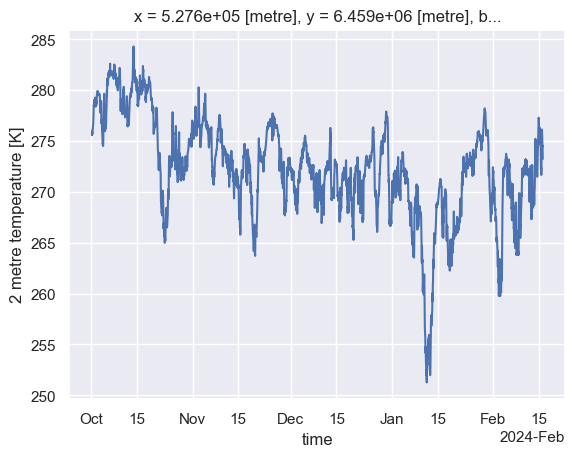

In [10]:
ds['temp'].plot()

## Check for missing dates and fill if missing 
Check there are no datetime gaps in the dataset, because Snow-17 is very strict and I've already had a problem with missing dates on 2023-10-29-00 <--- hour missing

In [14]:
def report_missing_hours(ds, time_var="time"):
    """
    Check for missing hourly timestamps in an xarray dataset.
    """
    time = pd.to_datetime(ds[time_var].values)

    # Expected hourly range
    full_range = pd.date_range(
        start=time.min(),
        end=time.max(),
        freq="1h"
    )

    missing = full_range.difference(time)

    if len(missing) == 0:
        print("No missing hourly timestamps.")
    else:
        print(f"Missing {len(missing)} hourly timestamps:")
        for t in missing:
            print(t)

    return missing

In [15]:
missing_times = report_missing_hours(ds)

Missing 1 hourly timestamps:
2023-10-29 00:00:00


And, create the CSV

## Create Forcing File

This version fills the missing data with interpolation, 

In [31]:
# --- 1. Convert temperature to Celsius ---
ds["tavg_degc"] = ds.temp - 273.15

# keep two decimals
ds["tavg_degc"] = ds.tavg_degc.round(2)

# --- 2. Precip rate already in mm/s ---
ds["prec_mm_s-1"] = ds.precip_rate # it must really be in mm per sec because otherwise everything breaks 
# ds["prec_mm_s-1"] = ds.precip_rate * 3600 # even though the forcing file says per second, I really think this must be precip accum over the timestep (1hr = 3600sec)

# --- 3. Convert to dataframe ---
df = ds[["prec_mm_s-1", "tavg_degc"]].to_dataframe().reset_index()

# --- 4. Build continuous hourly time index ---
df = df.set_index("time").sort_index()

full_time = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="1h"
)

df = df.reindex(full_time)

# --- 5. Fill missing values ---
# Precip: assume zero if missing
df["prec_mm_s-1"] = df["prec_mm_s-1"].fillna(0.0)

# Temperature: interpolate
df["tavg_degc"] = df["tavg_degc"].interpolate(method="time")

# --- 6. Restore time column ---
df = df.reset_index().rename(columns={"index": "time"})

# --- 7. Extract time components ---
df["year"] = df["time"].dt.year
df["mo"] = df["time"].dt.month
df["dy"] = df["time"].dt.day
df["hr"] = df["time"].dt.hour

# --- 8. Reorder columns ---
df_out = df[[
    "year",
    "mo",
    "dy",
    "hr",
    "prec_mm_s-1",
    "tavg_degc"
]]

# --- 9. Write to CSV ---
output_file = "/home/cassie/python/models/run_snow17/test1/input/forcing/forcing.snow17bmi.hrrrak_ppsa2_test1.csv"

df_out.to_csv(
    output_file,
    index=False,
    float_format="%.6e"
)

print(f"Forcing file written to: {output_file}")

Forcing file written to: /home/cassie/python/models/run_snow17/test1/input/forcing/forcing.snow17bmi.hrrrak_ppsa2_test1.csv


In [21]:
df_out

,year,mo,dy,hr,prec_mm_s-1,tavg_degc
0,2023,10,1,5,0.00100,2.48
1,2023,10,1,6,0.00060,2.44
2,2023,10,1,7,0.00040,2.80
3,2023,10,1,8,0.00120,2.49
4,2023,10,1,9,0.00071,2.74
...,...,...,...,...,...,...
3307,2024,2,16,0,0.00000,2.28
3308,2024,2,16,1,0.00000,1.28
3309,2024,2,16,2,0.00000,1.43
3310,2024,2,16,3,0.00000,0.55


In [29]:
# Check the final dataframe for any missing data 
df_out_rename = df_out.rename(columns={'mo':'month', 'dy':'day', 'hr':'hour'})
time = pd.to_datetime(df_out_rename[["year","month","day","hour"]]) 
dt = time.diff().dropna()

if not (dt == pd.Timedelta("1h")).all():
    raise ValueError("Forcing file still has time gaps.")
else:
    print("Forcing file has continuous hourly timestamps.")

Forcing file has continuous hourly timestamps.


This version does not deal with missing data, 

In [ ]:
# # --- 1. Convert temperature to Celsius ---
# ds["tavg_degc"] = ds.temp - 273.15 

# # save only two decimal places for the temperature (snow17 input is in whole degrees C, but we can keep as float for now and round when writing to csv)
# ds["tavg_degc"] = ds.tavg_degc.round(2)

# # --- 2. Precip rate already in mm/s ---
# ds["prec_mm_s-1"] = ds.precip_rate

# # --- 3. Convert to pandas dataframe ---
# df = ds[["prec_mm_s-1", "tavg_degc"]].to_dataframe().reset_index()

# # --- 4. Extract time components ---
# df["year"] = df["time"].dt.year
# df["mo"] = df["time"].dt.month
# df["dy"] = df["time"].dt.day
# df["hr"] = df["time"].dt.hour

# # --- 5. Reorder columns ---
# df_out = df[[
#     "year",
#     "mo",
#     "dy",
#     "hr",
#     "prec_mm_s-1",
#     "tavg_degc"
# ]]

# # --- 6. Write to CSV ---
# output_file = "/home/cassie/python/models/run_snow17/test1/input/forcing/forcing.snow17bmi.hrrrak_ppsa2_test1.csv"
# df_out.to_csv(
#     output_file,
#     index=False,
#     float_format="%.6e"  # scientific notation like example
# )

# print(f"Forcing file written to: {output_file}")

Forcing file written to: /home/cassie/python/models/run_snow17/test1/input/forcing/forcing.snow17bmi.hrrrak_ppsa2_test1.csv


## Create Params File

In [10]:
def write_snow17_params(
    output_file,
    hru_id,
    lat,
    lon,
    elev,
    area=1.0
):
    """
    Write a single-HRU Snow-17 parameter file (.txt).

    Parameters
    ----------
    hru_id : HRU identifier
    lat : latitude (deg)
    lon : longitude (deg) [not written to file, for metadata]
    elev : elevation (m)
    area : HRU area (km2), arbitrary for point runs
    """

    # Ensure .txt extension
    if not output_file.endswith(".txt"):
        output_file += ".txt"

    # Parameter values (typical default Snow-17 settings)
    params = [
        f"hru_id {hru_id}",
        f"hru_area {area}",
        f"latitude {lat}",
        f"elev {elev}",
        "scf 1.8",
        "mfmax 2.0",
        "mfmin 0.1",
        "uadj 0.05",
        "si 1500.0",
        "pxtemp 0.0",
        "nmf 0.15",
        "tipm 0.1",
        "mbase 0.0",
        "plwhc 0.03",
        "daygm 0.2",
        "adc1 0.05",
        "adc2 0.09",
        "adc3 0.16",
        "adc4 0.31",
        "adc5 0.54",
        "adc6 0.74",
        "adc7 0.84",
        "adc8 0.89",
        "adc9 0.93",
        "adc10 0.97",
        "adc11 1.00",
    ]

    with open(output_file, "w", encoding="ascii") as f:
        f.write("\n".join(params) + "\n")

    print(f"Snow-17 parameter file written to: {output_file}")

then use it, 

In [11]:
write_snow17_params(
    output_file="/home/cassie/python/models/run_snow17/test1/input/params/snow17_params.hrrrak_ppsa2_test1.txt",
    hru_id="hrrrak_ppsa2_test1",
    lat=58.262,
    lon=-134.517,
    elev=670
)

Snow-17 parameter file written to: /home/cassie/python/models/run_snow17/test1/input/params/snow17_params.hrrrak_ppsa2_test1.txt


## Params File Info

### HRU descriptors 
| Parameter  | Meaning             | Units              |
| ---------- | ------------------- | ------------------ |
| `hru_id`   | HRU name/identifier | text               |
| `hru_area` | Area of HRU         | km² or model units |
| `latitude` | Latitude of HRU     | degrees            |
| `elev`     | Mean elevation      | m                  |


### Snowfall and melt parameters 
| Parameter | Meaning                                   | Typical range   |
| --------- | ----------------------------------------- | --------------- |
| `scf`     | Snow correction factor (gauge undercatch) | 0.8–2.5         |
| `mfmax`   | Max melt factor (non-rain)                | 0.5–5 mm/°C/day |
| `mfmin`   | Min melt factor                           | 0–1 mm/°C/day   |
| `uadj`    | Wind function during rain-on-snow         | 0–0.5           |
| `si`      | Snow water equivalent at 100% cover       | mm              |
| `pxtemp`  | Rain–snow threshold temperature           | °C              |


### Snowpack energy and mass parameters 
| Parameter | Meaning                             | Typical range |
| --------- | ----------------------------------- | ------------- |
| `nmf`     | Negative melt factor                | ~0.1–0.3      |
| `tipm`    | Antecedent temperature index weight | 0–1           |
| `mbase`   | Base melt temperature               | °C            |
| `plwhc`   | Liquid water holding capacity       | 0.01–0.1      |
| `daygm`   | Daily ground melt                   | 0–0.5 mm/day  |


### Areal depletion curve (ADC)
These describe fractional snow cover vs SWE
| Parameter      | Meaning                                      |
| -------------- | -------------------------------------------- |
| `adc1`–`adc11` | Snow cover fraction at increasing SWE levels |


## Open Example / Test Case Files

Start by opening an example input file, 

In [17]:
# open /home/cassie/python/models/run_snow17/examples/input/forcing/forcing.snow17bmi.HHWM8IL.csv
forcing_file_L = '/home/cassie/python/models/run_snow17/examples/input/forcing/forcing.snow17bmi.HHWM8IL.csv'
forcing_file_U = '/home/cassie/python/models/run_snow17/examples/input/forcing/forcing.snow17bmi.HHWM8IU.csv'
df_L = pd.read_csv(forcing_file_L)
df_U = pd.read_csv(forcing_file_U)

df_L.head()

,year,mo,dy,hr,prec_mm_s-1,tavg_degc
0,1970,1,1,12,0.000005,-9.35
1,1970,1,2,12,0.000004,-9.23
2,1970,1,3,12,0.000009,-11.84
3,1970,1,4,12,0.000009,-13.45
4,1970,1,5,12,0.000008,-18.82


In [19]:
# rename the 5th column to be precip_rate_mm_s
df_L.rename(columns={df_L.columns[4]: 'prec_mm_s'}, inplace=True)
df_U.rename(columns={df_U.columns[4]: 'prec_mm_s'}, inplace=True)
df_U.head()

,year,mo,dy,hr,prec_mm_s,tavg_degc
0,1970,1,1,12,0.000013,-7.38
1,1970,1,2,12,0.000051,-8.08
2,1970,1,3,12,0.000003,-10.13
3,1970,1,4,12,0.000003,-11.03
4,1970,1,5,12,0.000005,-15.37


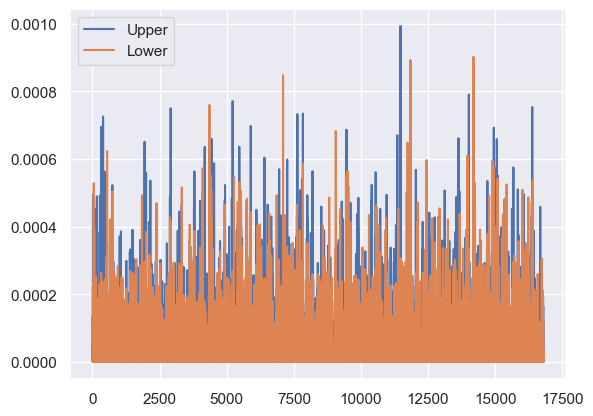

In [26]:
df_U.prec_mm_s.plot()
df_L.prec_mm_s.plot()
plt.legend(['Upper', 'Lower'])